In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import RFE
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


In [12]:
Data=pd.read_csv("healthcare-dataset-stroke-data.csv")

In [6]:
print(df.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [7]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())


In [8]:
print(df.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [13]:
Data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [14]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


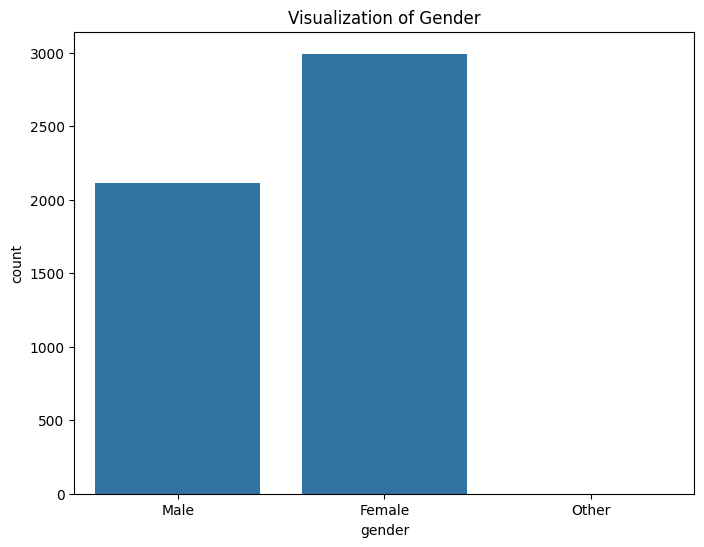

In [15]:
plt.figure(figsize=(8,6))
sns.countplot(data=Data, x='gender')
plt.title('Visualization of Gender')
plt.show()


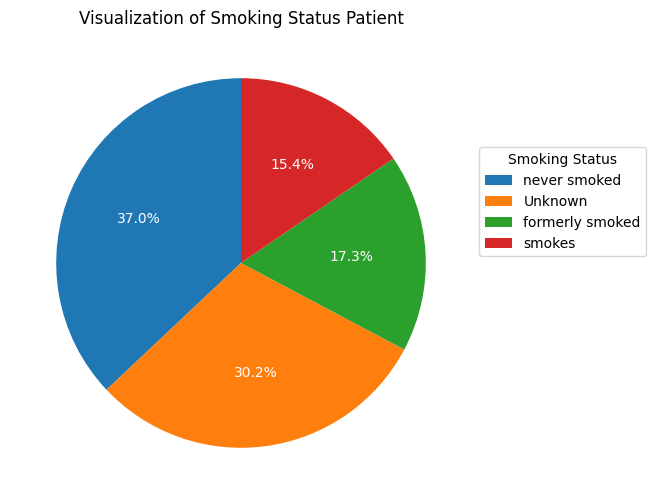

In [16]:
count_smoking=Data['smoking_status'].value_counts()
plt.figure(figsize=(6,6))
wedges,texts, autotexts=plt.pie(
    count_smoking.values,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.6,
    textprops={'color':'white'}
)

plt.title('Visualization of Smoking Status Patient')
plt.legend(wedges, count_smoking.index, title="Smoking Status", loc="lower left", bbox_to_anchor=(1,0.5))

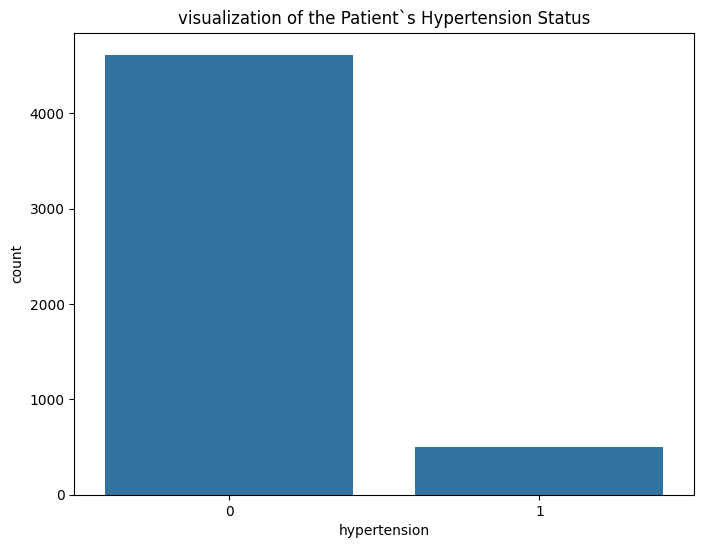

In [17]:
plt.figure(figsize=(8,6))
sns.countplot(data=Data, x='hypertension')
plt.title('visualization of the Patient`s Hypertension Status')
plt.show()

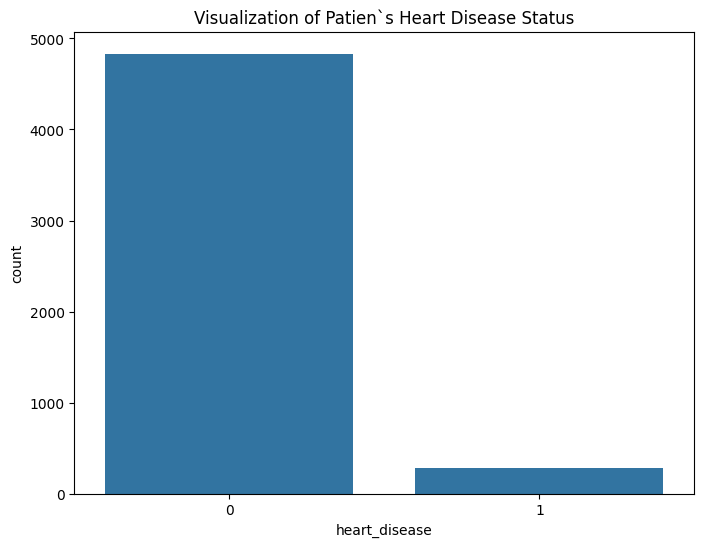

In [18]:
plt.figure(figsize=(8,6))
sns.countplot(data=Data, x='heart_disease')
plt.title('Visualization of Patien`s Heart Disease Status')
plt.show()


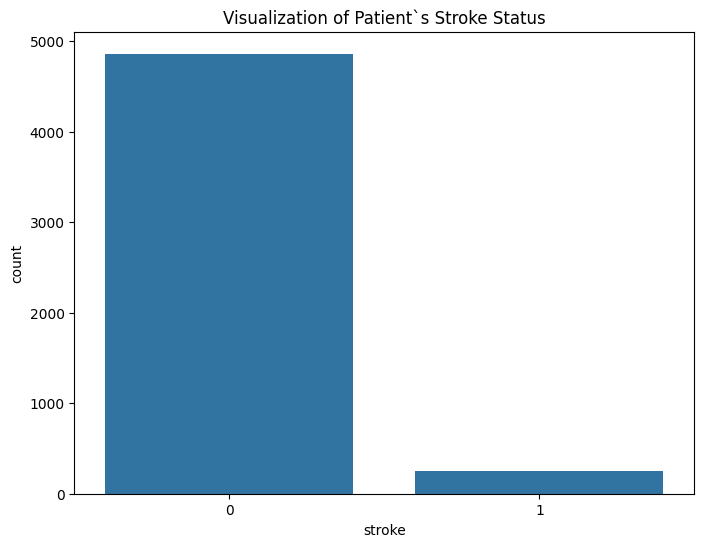

In [19]:
plt.figure(figsize=(8,6))
sns.countplot(data=Data, x='stroke')
plt.title('Visualization of Patient`s Stroke Status')
plt.show()


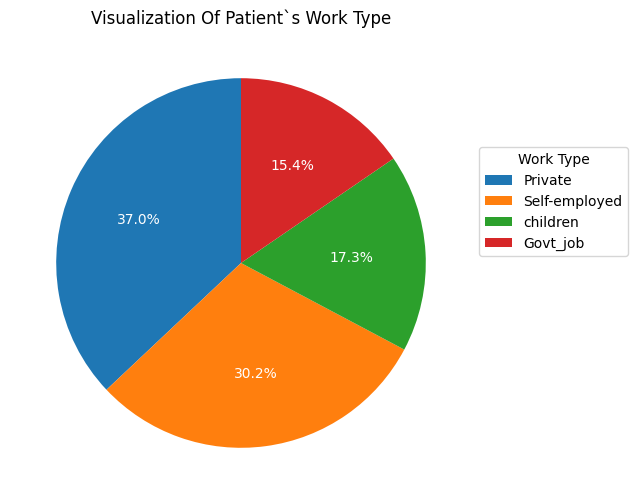

In [20]:
count_work=Data['work_type'].value_counts()
plt.figure(figsize=(6,6))
wedges, texts, autotexts=plt.pie(
    count_smoking.values,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.6,
    textprops={'color':'white'}
)
plt.title('Visualization Of Patient`s Work Type')
plt.legend(wedges, count_work.index, title='Work Type', loc='lower left', bbox_to_anchor=(1,0.5))
plt.show()

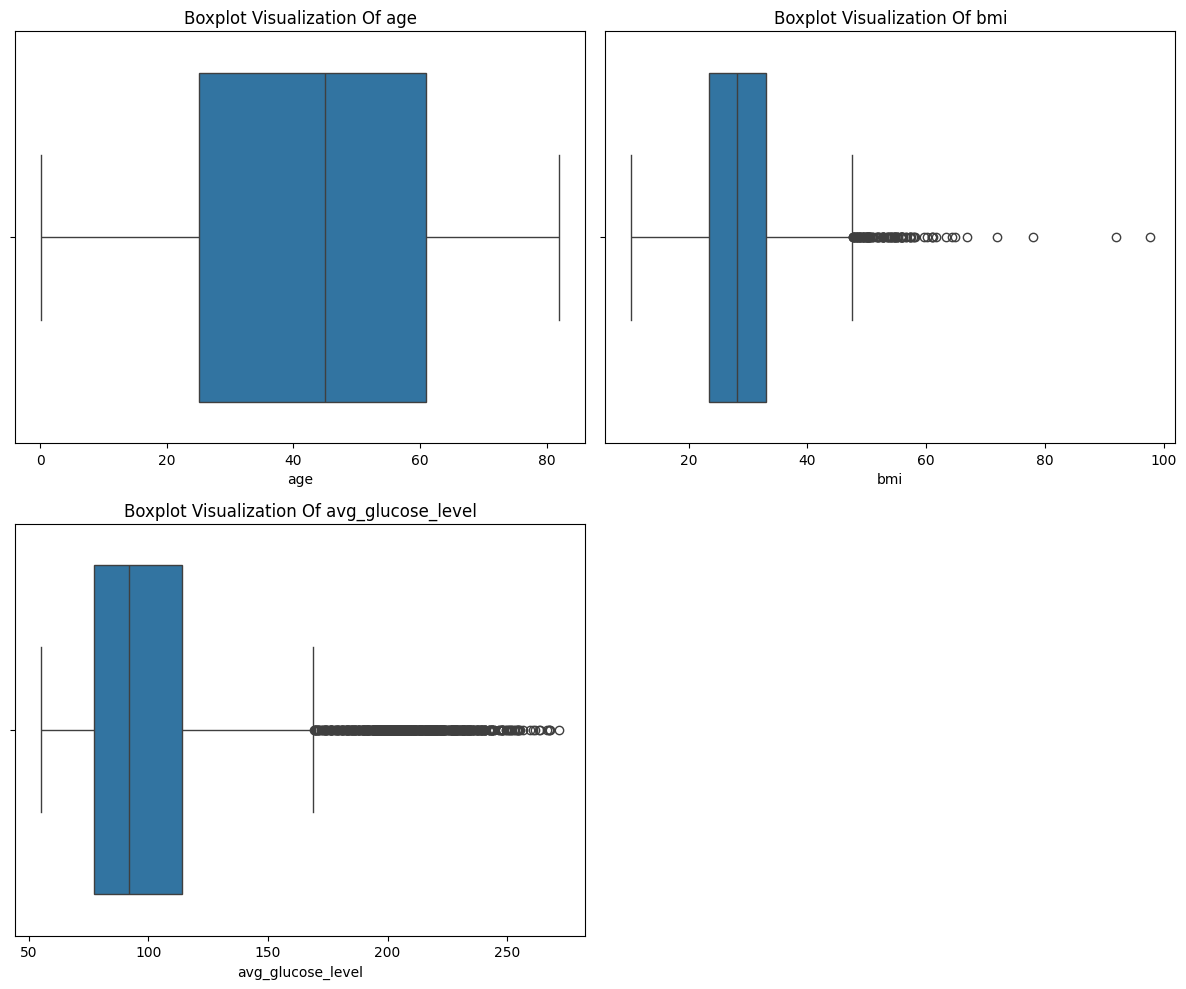

In [21]:
num_category=['age','bmi','avg_glucose_level']
fig, axs=plt.subplots(2,2, figsize=(12,10))
axs=axs.flatten()

for i, feature in enumerate(num_category):
    sns.boxplot(data=Data, x=feature, ax=axs[i])
    axs[i].set_title(f'Boxplot Visualization Of {feature}')
    axs[i].set_xlabel(feature)

fig.delaxes(axs[-1])
plt.tight_layout()
plt.show()

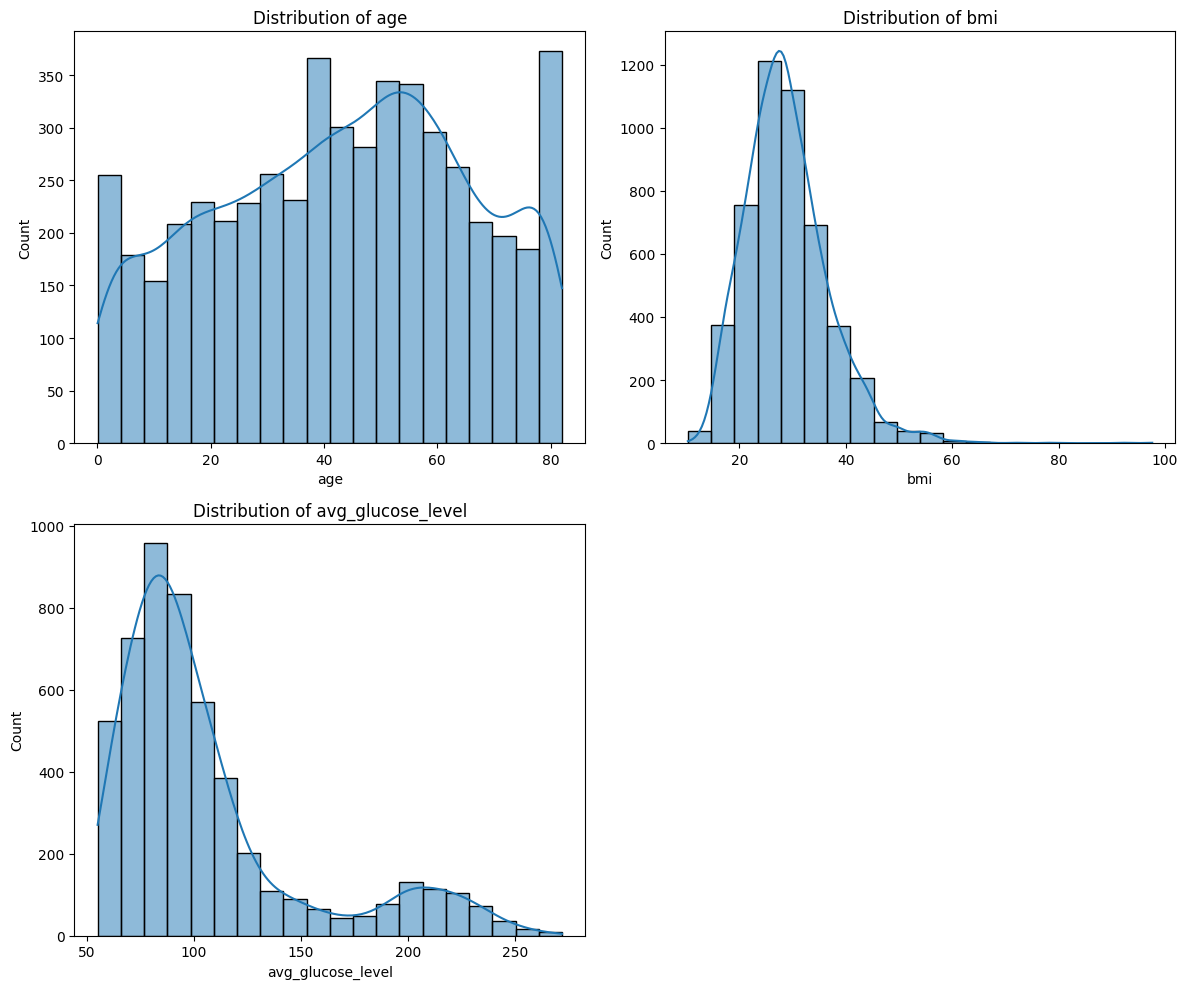

In [22]:
fig, axs=plt.subplots(2,2, figsize=(12,10))
axs=axs.flatten()
for i, feature in enumerate(num_category):
    sns.histplot(Data[feature], bins=20, kde=True, edgecolor='black', ax=axs[i])
    axs[i].set_title(f'Distribution of {feature}')
    axs[i].set_xlabel(feature)
    plt.ylabel('Count')

fig.delaxes(axs[-1])
plt.tight_layout()
plt.show()

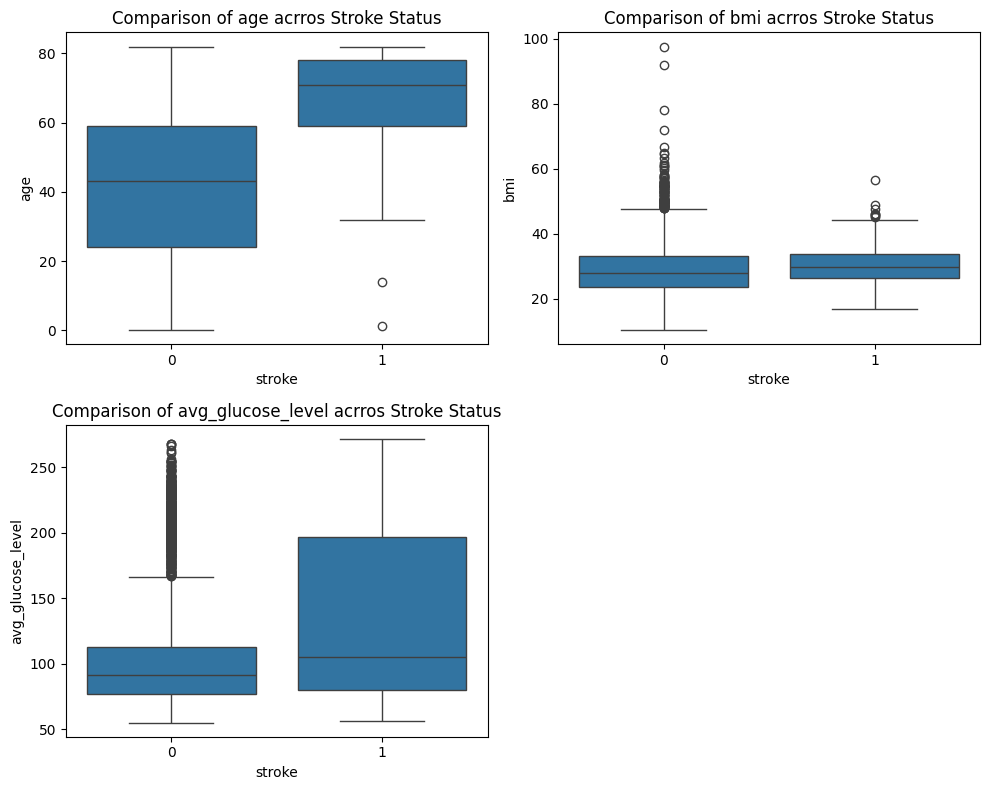

In [23]:
Patient_Data=['age','bmi','avg_glucose_level']
fig, axs=plt.subplots(2,2, figsize=(10,8))
axs=axs.flatten()
for i, col in enumerate(Patient_Data):
    sns.boxplot(data=Data, x='stroke', y=col, ax=axs[i])
    axs[i].set_title(f'Comparison of {col} acrros Stroke Status')

fig.delaxes(axs[-1])
plt.tight_layout()
plt.show()


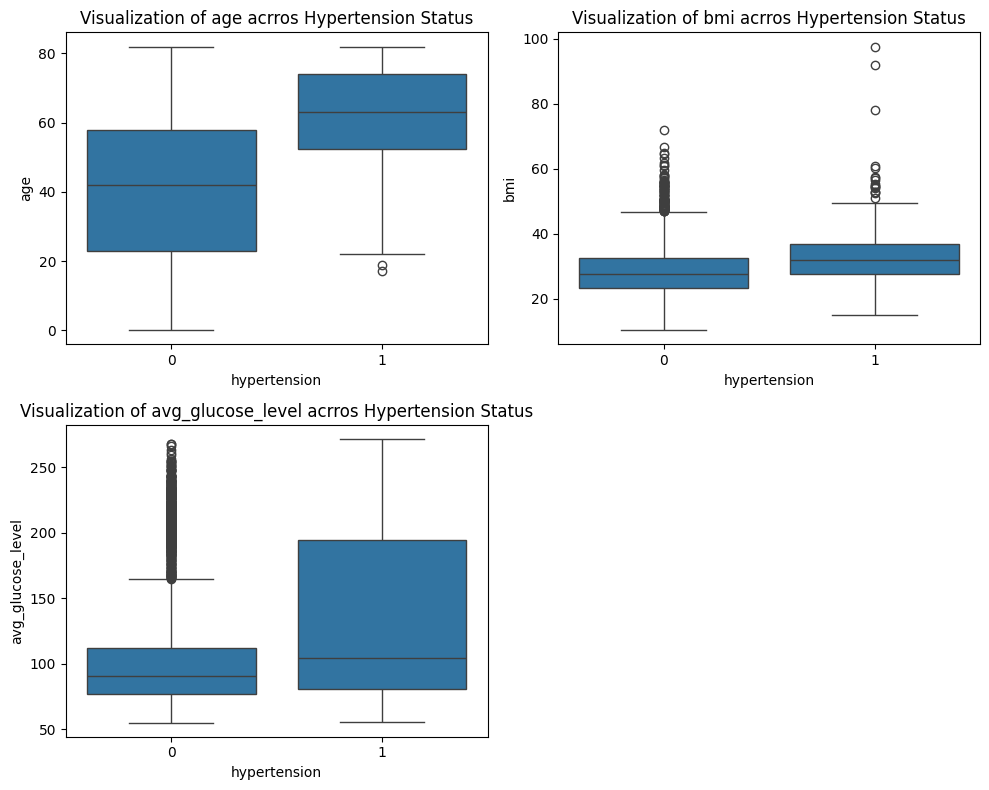

In [24]:
fig, axs=plt.subplots(2,2, figsize=(10,8))
axs=axs.flatten()
for i, feature in enumerate(Patient_Data):
    sns.boxplot(data=Data, x='hypertension', y=feature, ax=axs[i])
    axs[i].set_title(f'Visualization of {feature} acrros Hypertension Status')

fig.delaxes(axs[-1])
plt.tight_layout()
plt.show()

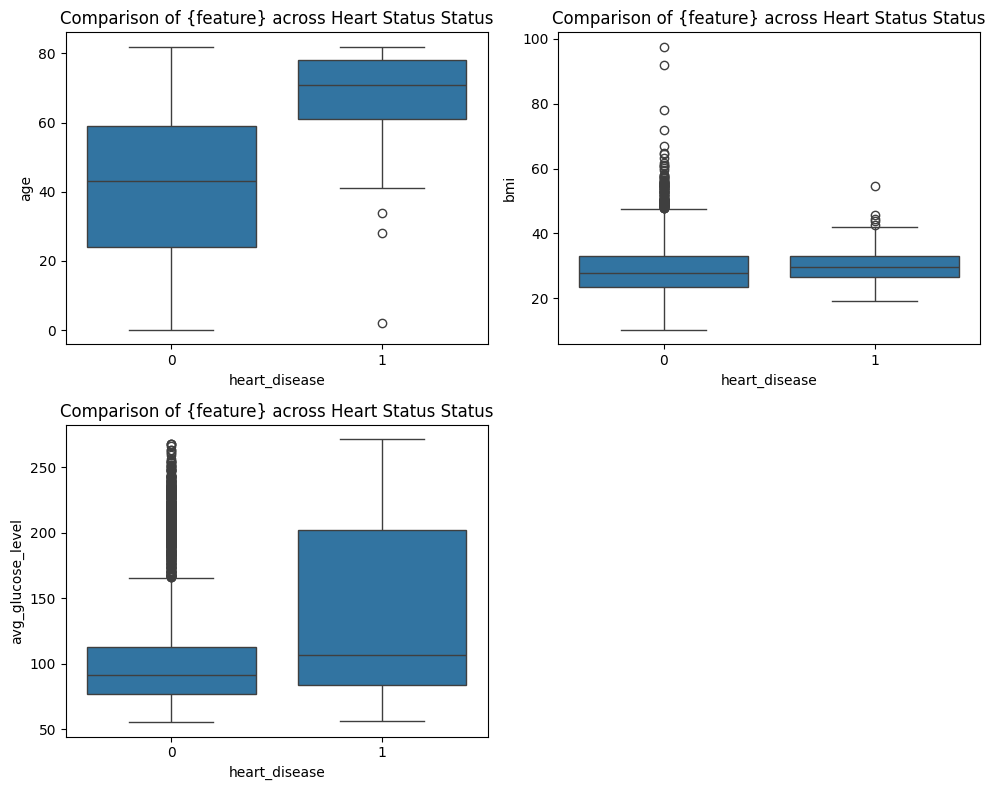

In [25]:
fig, axs=plt.subplots(2,2, figsize=(10,8))
axs=axs.flatten()
for i, feature in enumerate(Patient_Data):
    sns.boxplot(data=Data, x='heart_disease', y=feature, ax=axs[i])
    axs[i].set_title('Comparison of {feature} across Heart Status Status')

fig.delaxes(axs[-1])
plt.tight_layout()
plt.show()


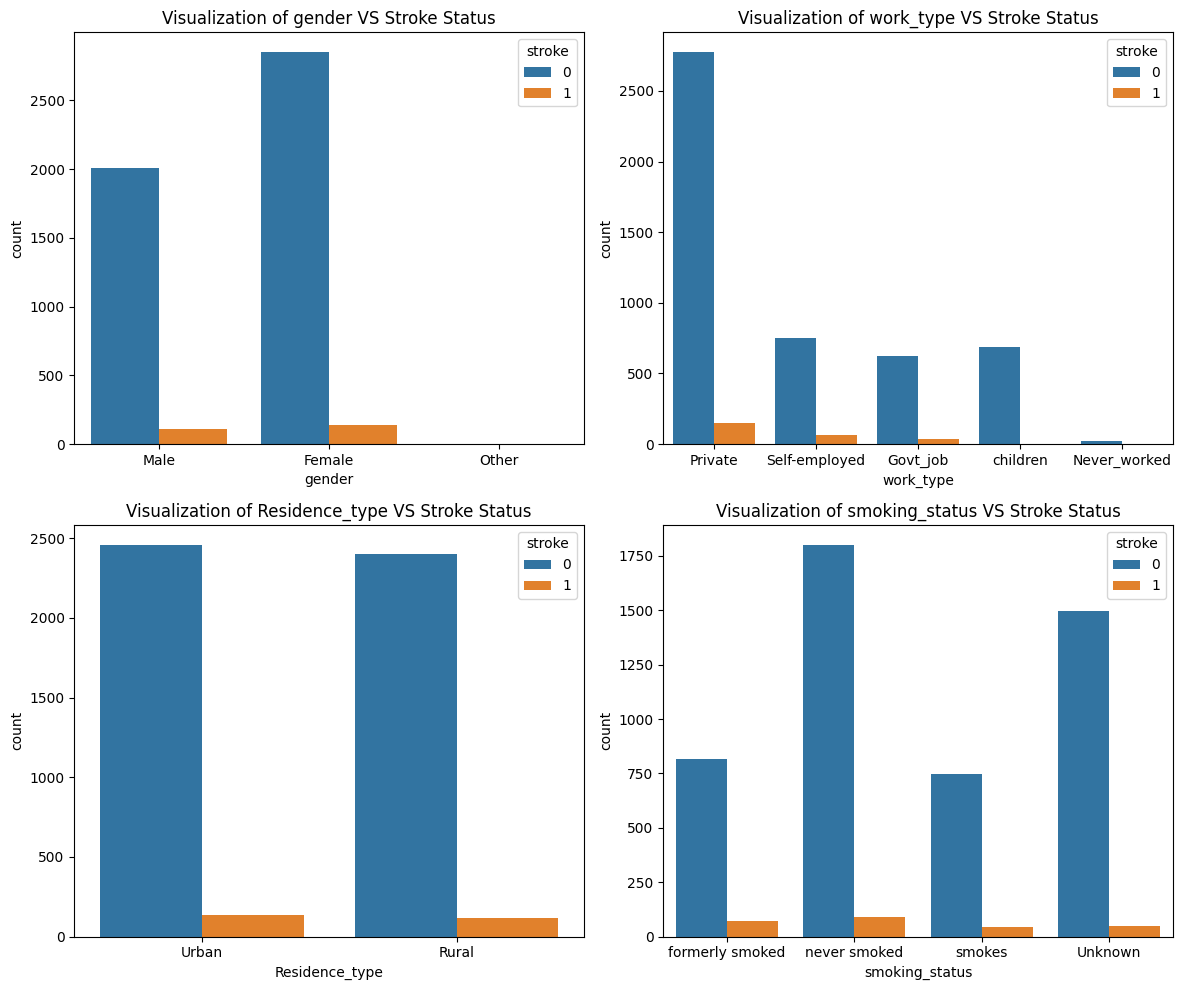

In [26]:
Patient_status=['gender','work_type','Residence_type','smoking_status']
fig, axs=plt.subplots(2,2, figsize=(12,10))
axs=axs.flatten()
for i, feature in enumerate(Patient_status):
    sns.countplot(data=Data, x=feature, hue='stroke', ax=axs[i])
    axs[i].set_title(f'Visualization of {feature} VS Stroke Status')
    axs[i].set_xlabel(feature)

plt.tight_layout()
plt.show()

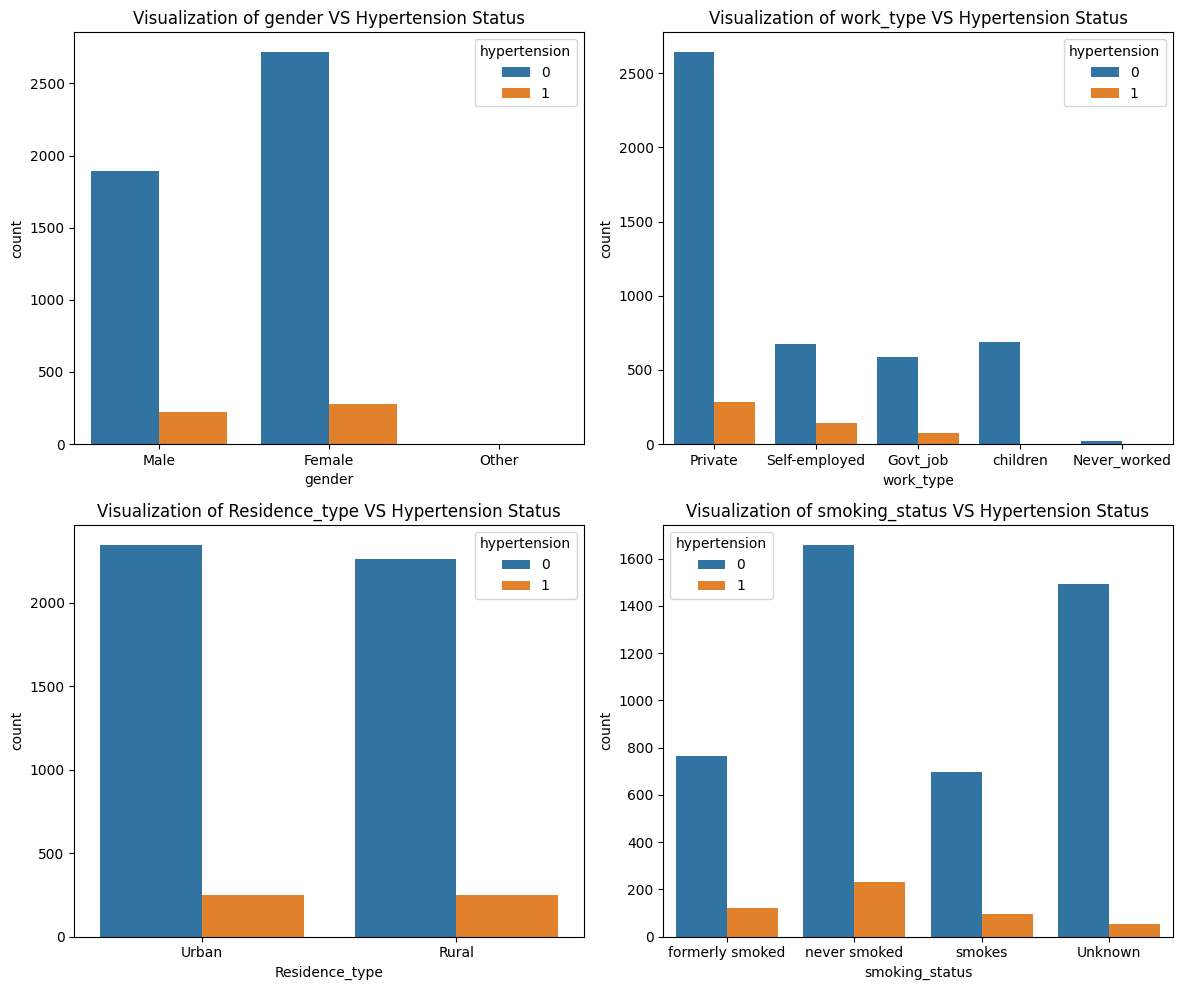

In [27]:
fig, axs=plt.subplots(2,2, figsize=(12,10))
axs=axs.flatten()
for i, feature in enumerate(Patient_status):
    sns.countplot(data=Data, x=feature, hue='hypertension', ax=axs[i])
    axs[i].set_title(f'Visualization of {feature} VS Hypertension Status')
    axs[i].set_xlabel(feature)

plt.tight_layout()
plt.show()

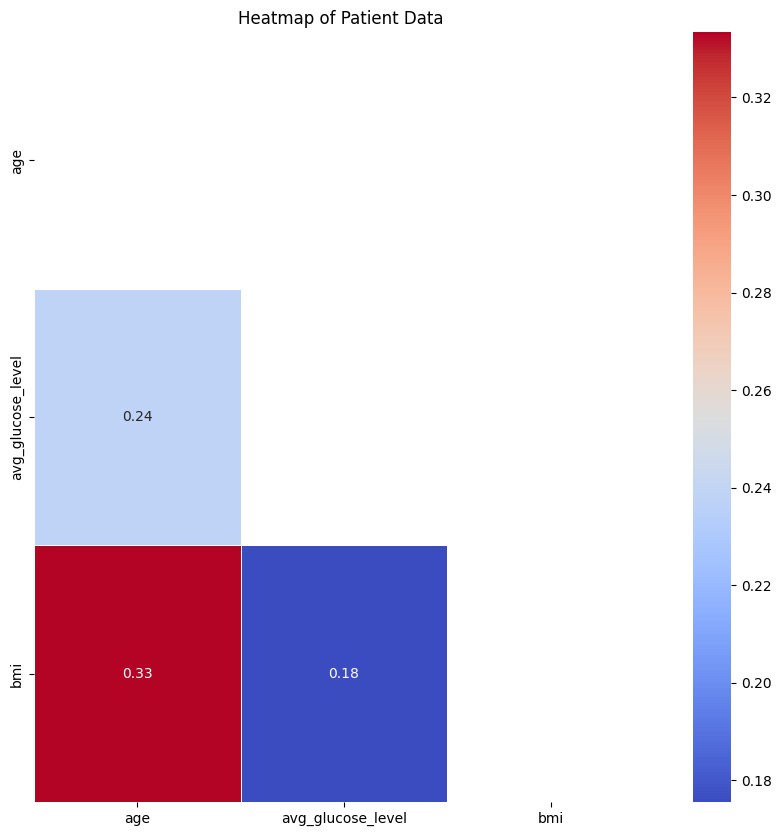

In [28]:
Num_column=Data[['age','avg_glucose_level','bmi']]
corr_num=Num_column.corr()
mask=np.triu(np.ones_like(corr_num, dtype=bool))
plt.figure(figsize=(10,10))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', linewidths=0.5, mask=mask, fmt='.2f')
plt.title('Heatmap of Patient Data ')
plt.show()

In [29]:
Data=Data[Data['gender'] !='Other']

In [30]:
Gender_encode={
    'Male':0,
    'Female':1
}
ever_married_encode={
    'Yes':0,
    'No':1
}
work_type_encode={
    'Private':0,
    'Self-employed':1,
    'children':2,
    'Govt_job':3,
    'Never_worked':4
}
Resident_encode={
    'Urban':0,
    'Rural':1
}
smoking_encode={
    'never smoked':0,
    'formerly smoked':1,
    'smokes':2,
    'Unknown':3
}

In [31]:
Data['gender']=Data['gender'].map(Gender_encode)
Data['ever_married']=Data['ever_married'].map(ever_married_encode)
Data['Residence_type']=Data['Residence_type'].map(Resident_encode)
Data['smoking_status']=Data['smoking_status'].map(smoking_encode)
Data['work_type']=Data['work_type'].map(work_type_encode)

In [32]:
Data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,0,67.0,0,1,0,0,0,228.69,36.6,1,1
1,51676,1,61.0,0,0,0,1,1,202.21,NaN,0,1
2,31112,0,80.0,0,1,0,0,1,105.92,32.5,0,1
3,60182,1,49.0,0,0,0,0,0,171.23,34.4,2,1
4,1665,1,79.0,1,0,0,1,1,174.12,24.0,0,1


In [33]:
scaler=MinMaxScaler()
Data['age']=scaler.fit_transform(Data[['age']])
Data['avg_glucose_level']=scaler.fit_transform(Data[['avg_glucose_level']])
Data['bmi']=scaler.fit_transform(Data[['bmi']])
Data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,0,0.816895,0,1,0,0,0,0.801265,0.301260,1,1
1,51676,1,0.743652,0,0,0,1,1,0.679023,NaN,0,1
2,31112,0,0.975586,0,1,0,0,1,0.234512,0.254296,0,1
3,60182,1,0.597168,0,0,0,0,0,0.536008,0.276060,2,1
4,1665,1,0.963379,1,0,0,1,1,0.549349,0.156930,0,1


In [34]:
X=Data.drop('stroke', axis=1)
y=Data['stroke']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

print(f"Training Data Shape: X_train:{X_train.shape}, y_train:{y_train.shape} ")
print(f"Testing Data Shape: X_test{X_test.shape}, y_test:{y_test.shape}")

Training Data Shape: X_train:(4087, 11), y_train:(4087,) 
Testing Data Shape: X_test(1022, 11), y_test:(1022,)


In [35]:
train_df=X_train.copy()
train_df['stroke']=y_train

stroke_majority=train_df[train_df['stroke']==0]
stroke_minority=train_df[train_df['stroke']==1]

stroke_minority_oversample=resample(
    stroke_minority,
    replace=True,
    n_samples=len(stroke_majority),
    random_state=42
)

train_balanced=pd.concat([stroke_majority, stroke_minority_oversample])
train_balanced=train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_train=train_balanced.drop(columns=['stroke'])
y_train=train_balanced['stroke']

In [38]:
from sklearn.impute import SimpleImputer

# Impute NaN values in numeric features (like bmi)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

LR = LogisticRegression(max_iter=1000).fit(X_train, y_train)

eval_train_LR = LR.predict(X_train)
eval_test_LR  = LR.predict(X_test)

# Evaluate
acc_lr = accuracy_score(y_test, eval_test_LR)
precision_lr = precision_score(y_test, eval_test_LR)
recall_lr = recall_score(y_test, eval_test_LR)
f1_lr = f1_score(y_test, eval_test_LR)

print('Data Train')
print(classification_report(y_train, eval_train_LR))

print("="*50)

print('Data Test')
print(classification_report(y_test, eval_test_LR))


Data Train
              precision    recall  f1-score   support

           0       0.80      0.74      0.77      3900
           1       0.76      0.81      0.78      3900

    accuracy                           0.78      7800
   macro avg       0.78      0.78      0.78      7800
weighted avg       0.78      0.78      0.78      7800

Data Test
              precision    recall  f1-score   support

           0       0.98      0.73      0.84       960
           1       0.16      0.79      0.26        62

    accuracy                           0.73      1022
   macro avg       0.57      0.76      0.55      1022
weighted avg       0.93      0.73      0.80      1022



In [40]:
DT=DecisionTreeClassifier().fit(X_train, y_train)
eval_train_dt=DT.predict(X_train)
eval_test_dt=DT.predict(X_test)

acc_dt=accuracy_score(eval_test_dt, y_test)
precision_dt=precision_score(eval_test_dt, y_test)
recall_dt=recall_score(eval_test_dt, y_test)
f1_dt=f1_score(eval_test_dt, y_test)
print('Data Train')
print(classification_report(y_train, eval_train_dt))

print('='*50)
print('Data Test')
print(classification_report(y_test, eval_test_dt))

Data Train
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3900
           1       1.00      1.00      1.00      3900

    accuracy                           1.00      7800
   macro avg       1.00      1.00      1.00      7800
weighted avg       1.00      1.00      1.00      7800

Data Test
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       960
           1       0.10      0.08      0.09        62

    accuracy                           0.90      1022
   macro avg       0.52      0.52      0.52      1022
weighted avg       0.89      0.90      0.90      1022



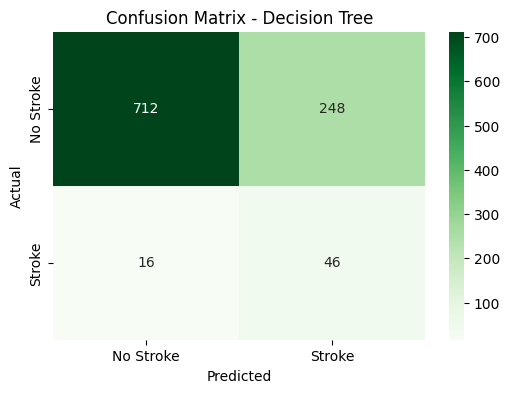

Decision Tree Report
              precision    recall  f1-score   support

           0       0.98      0.74      0.84       960
           1       0.16      0.74      0.26        62

    accuracy                           0.74      1022
   macro avg       0.57      0.74      0.55      1022
weighted avg       0.93      0.74      0.81      1022



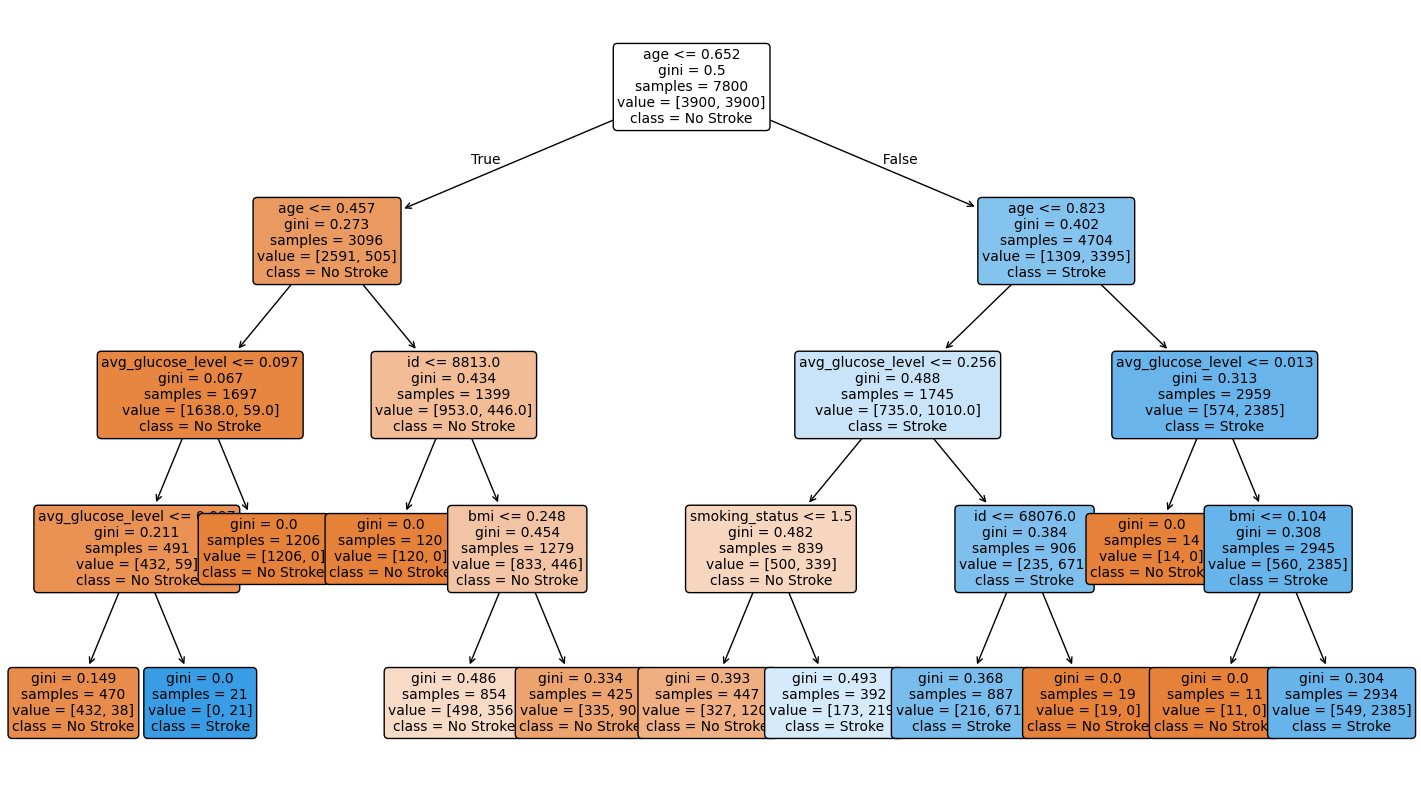

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report

# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Stroke','Stroke'],
            yticklabels=['No Stroke','Stroke'])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Decision Tree Report")
print(classification_report(y_test, y_pred_dt))

# Visualize the Decision Tree
plt.figure(figsize=(18,10))
plot_tree(dt, feature_names=X.columns, class_names=["No Stroke","Stroke"],
          filled=True, rounded=True, fontsize=10)
plt.show()
